In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import conductivity_new as cd

# Conductivity of Simple Ionic Mixtures

# Double Salts Prediction

## Data for Double Salts

In [2]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/LiCL_pH.csv")
LiCl_conc = data["LiCl_conc"]
HCl_conc_ph2 = data["HCl_conc_ph2"]
HCl_conc_ph3 = data["HCl_conc_ph3"]
HCl_conc_ph4 = data["HCl_conc_ph4"]

# number of data points
ndata = len(LiCl_conc)

## Constants

In [3]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_Li = 1.029 * 10**(-9)
Diff_H = 9.311 * 10**(-9)
Diff_Co = 0.732 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_Li = 1
z_H = 1

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 103.2 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_Li = 2 * 74 * 10**(-12)
sigma_H = 2 * 37 * 10**(-12)
sigma_Co = 2 * 74.5 * 10**(-12)

# solvent viscosity in Pa.s
eta = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Li_mol = 38.66 * 10**(-4)
lambda_0_H_mol = 349.65 * 10**(-4)
lambda_0_Co_mol = 55 * 10**(-4)

## MSA Transport Model

### pH 2 LiCl and HCl

In [4]:
# Mean spherical approximation (MSA) transport model for multi-salt specific conductivity
def msa_transport(valency, diameters, diff_coeff, temp, eta, epsilon, lambda_0,
                  salt_1_conc, salt_2_conc=None, salt_3_conc=None):
    """Calculates the specific conductivity of single-salt, two-salt, and three-salt solutions

    Argument:
        valency: list of the valency of ions in decreasing order
        diameters: list of the corresponding hard sphere diameter of the ions in m
        diff_coeff: list of the corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        temp: integer or float value of the temperature in K
        sensor_voltage: integer or float value of the sensor measuring voltage in V
        probe_distance: integer or float value of the distance between the probes in m
        eta: integer or float value of the viscosity in Pa.s
        epsilon: integer or float value of the relative permittivity
        lambda_0: list of the limiting equivalent conductivity of the ions in S.m^2/mol
        salt_1_conc = Pandas series or list of the concentration of salt 1 in mM
        salt_2_conc = Pandas series or list of the concentration of salt 2 in mM
        salt_3_conc = Pandas series or list of the concentration of salt 3 in mM

    Returns:
        all_cond_calc_con: specific conductivity of the salt solution in micro.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10 ** 23  # Avogadro's constant
    k_B = 1.381 * 10 ** (-23)  # Boltzmann constant in J/K
    charge = 1.602 * 10 ** (-19)  # elementary charge in C
    epsilon_0 = 8.854 * 10 ** (-12)  # permittivity of free space in F/m
    Faraday = 96500  # Faraday's constant in C/mol

    # number of data points
    ndata = len(salt_1_conc)

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # converting molar concentrations to number density
    if salt_2_conc is None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cation
        valency_cation = valency[0]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_an = [valency_cation * number_density_salt_1[i] for i in range(ndata)]
    elif salt_2_conc is not None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[1]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             for i in range(ndata)]
    else:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_3 = [salt_3_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[1]
        valency_cation_3 = valency[2]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_cat_3 = number_density_salt_3
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             + valency_cation_3 * number_density_salt_3[i] for i in range(ndata)]

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = np.zeros(ndata)
    for n in range(ndata):  # loop through the salts concentration
        if salt_2_conc is None and salt_3_conc is None:
            # number density of species
            n_cat = number_density_cat_1[n]
            n_an = number_density_an[n]
            number_density = [n_cat, n_an]
        elif salt_2_conc is not None and salt_3_conc is None:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_cat_2, n_an]
        else:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_cat_3 = number_density_cat_3[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_cat_2, n_cat_3, n_an]

        # calculate the species ionic mobility (omega) and the relative ionic strength (mew)
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a] / (k_B * temp)
            mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
                number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

        # calculate the Debye length from equation (5)
        kappa = math.sqrt(
            sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * temp) for l in range(n_species)))

        # calculate the mean mobility from equation (7)
        omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

        # calculate the transport number of all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j] * omega[j] / omega_bar

        # calculate the value of alpha from the function containing alpha
        alpha_scaled = np.zeros(n_species)
        def func_alpha(alpha_scaled):
            """
            Evaluates residuals of equation 12

            Arguments:
                alpha_scaled = alpha/omega_bar

            Returns:
                residual of equation 12
            """
            return ((alpha_scaled) * sum(
                transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

        # since alpha is scaled by omega_bar, omega need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
            omega_scaled[k] = omega[k] / omega_bar

        print("Scaled omega",omega_scaled)
        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.5 * omega_scaled[p - 1], 0.5 * omega_scaled[p])

        # re-scaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

        # calculate the q and N values of all species
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        for p in range(n_species):
            q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1 / sum(
                transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

        # ksi matrix
        ksi = np.zeros((n_species, n_species))

        # calculate the hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        for i in range(n_species):
            # update the hydrodynamic correction; equation (16) divide equation (2)
            prefactor = -(Faraday ** 2) * np.abs(valency[i]) / (
                        12 * math.pi * epsilon_0 * epsilon * eta * k_B * temp * Avogadros_num * lambda_0[i])
            delta_vel_divide_vel[i] = prefactor * sum(number_density[j] * ion_charge[j] ** 2 *
                                                      ((np.exp(kappa * (diameters[i] - 0.5 * (
                                                                  diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[i]))) +
                                                       (np.exp(kappa * (diameters[j] - 0.5 * (
                                                                   diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[j]))))
                                                      for j in range(n_species))

            # update the ksi matrix
            for p in range(n_species):
                ksi[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

        # calculate the conductivity of the species
        cond_species = np.zeros(n_species)

        # calculate the relaxation correction
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculate the average diameter
                        sigma_aj = 0.5 * (diameters[a] + diameters[j])

                        # first fraction of summation term
                        term1 = transport_num[j] * ksi[j][p] * mew[a] * (
                                ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                        ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                        # second fraction of summation term
                        term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                        # evaluate the integral term
                        integral_prefactor = - (charge ** 2 * valency[a] * valency[j]) / (
                                    8 * math.pi * epsilon_0 * epsilon * k_B * temp)

                        integral_term1 = np.exp(kappa * diameters[j]) / (1 + kappa * diameters[j])
                        integral_term2 = np.exp(kappa * diameters[a]) / (1 + kappa * diameters[a])

                        integral_exp_term = np.exp(-kappa * (1 + np.sqrt(q[p])) * sigma_aj) / (
                                    kappa * (1 + np.sqrt(q[p])))

                        integral = integral_prefactor * (integral_term1 + integral_term2) * integral_exp_term

                        inner_delta_k_divide_k_sum += term1 * term2 * integral

                delta_k_divide_k_sum += ksi[i][p] * inner_delta_k_divide_k_sum

            # update the relaxation correction
            delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

            # update the conductivity of the species
            cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                    1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * temp)

        # calculate the bulk conductivity of the solution
        all_cond_calc[n] = sum(cond_species)

    # convert the calculated conductivity from S/m to micro.S/cm
    cond_calc_con = [all_cond_calc[i] * 10 ** 6 / 100 for i in range(ndata)]

    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

In [5]:
# LiCl constants
diffusion_coeff_LiCl = [Diff_Li, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency_LiCl = [z_Li, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter_LiCl = [sigma_Li, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol]

# LiCl and HCl constants
diffusion_coeff = [Diff_Li, Diff_H, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Li, z_H, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Li, sigma_H, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_H_Cl = [lambda_0_Li_mol, lambda_0_H_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con_LiCl = cd.msa_transport(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, eta, epsilon, lambda_0_Li_Cl, LiCl_conc)
all_cond_calc_con_ph2 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph2)
all_cond_calc_con_ph3 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph3)
all_cond_calc_con_ph4 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph4)

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
omega_bar: 371710510737.0421
Alpha: [0.0, 351189115250.81476]
Mew: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Omega: [2.49911869e+11 4.93509152e+11]
ksi: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]
Relaxation correction: [ 0.00547254 -0.09593074 -0.05327301]
Hydrodynamic correction: [-0.16605101 -0.01886952 -0.07831106]
omega_bar: 539330376245.2738
Alpha: [0.0, 1842278565247.0852, 493509152445.17]
Mew: [0.41666667 0.08333333 0.5       ]
Transport number: [0.19307265 0.34940708 0.45752026]
Omega: [2.49911869e+11 2.26135026e+12 4.93509152e+11]
ksi: [[ 1.78268710e+00 -9.55397637e-02 -8.98330112e-13]
 [ 1.97012676e-01  1.67476169e+00  3.02260586e-13]
 [ 9.02748535e-01 -1.99510479e-01  1.47840980e+00]]
Relaxation correction: [ 0.00066163 -0.10234307 -0.04140458]
Hydrodynamic correction: [-0.15439489 -0.01751028 -0.07315768]
omega_bar: 391430494914.4811
Alpha: [0.0, 2198761

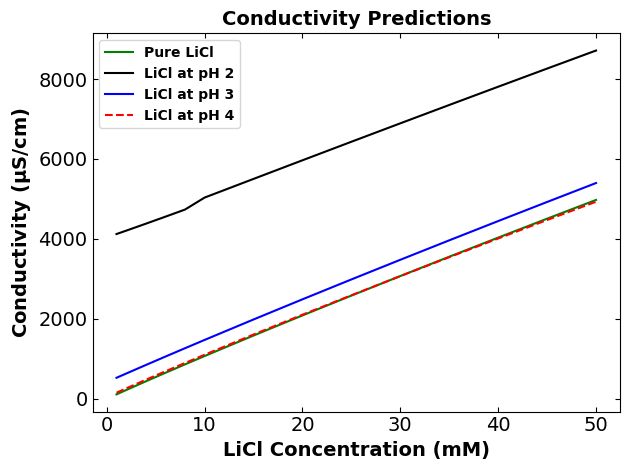

In [6]:
# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure()
plt.plot(LiCl_conc, all_cond_calc_con_LiCl, "g-", label="Pure LiCl")
plt.plot(LiCl_conc, all_cond_calc_con_ph2, color="black", linestyle="-", label="LiCl at pH 2")
plt.plot(LiCl_conc, all_cond_calc_con_ph3, "b-", label="LiCl at pH 3")
plt.plot(LiCl_conc, all_cond_calc_con_ph4, color='red', linestyle='--', label="LiCl at pH 4")
plt.xlabel("LiCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Conductivity Predictions", fontsize=14,fontweight='bold')
plt.legend()
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig("msa_licl_ph.png")
plt.show()